## Data Exploration / Cleaning

In [19]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import colorsys
sns.set_theme(style="whitegrid")

pio.renderers.default = "browser"
#pio.renderers.default = "notebook_connected"

In [3]:
# ============================
# 1. Load datasets
# ============================
train_df = pd.read_csv("/Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/PythonProject/HousingRegressionMLE/data/raw/train.csv")
eval_df = pd.read_csv("/Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/PythonProject/HousingRegressionMLE/data/raw/eval.csv")
metros = pd.read_csv("/Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/PythonProject/HousingRegressionMLE/data/raw/usmetros.csv")

pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows

print(train_df.shape)
print(eval_df.shape)

(585244, 39)
(149424, 39)


In [4]:
print(train_df.shape)
print(eval_df.shape)

(585244, 39)
(149424, 39)


In [5]:
train_df['city_full'].value_counts().head()

city_full
New York-Newark-Jersey City       78020
Chicago-Naperville-Elgin          35344
Los Angeles-Long Beach-Anaheim    33840
Philadelphia-Camden-Wilmington    31396
DC_Metro                          29516
Name: count, dtype: int64

### Map cities to Lat/Long
- The goal is to use Lattitude and longitude instead of cities for our ML models

In [6]:
# ============================
# 2. Fix city name mismatches
# ============================
city_mapping = {
    'Las Vegas-Henderson-Paradise': 'Las Vegas-Henderson-North Las Vegas',
    'Denver-Aurora-Lakewood': 'Denver-Aurora-Centennial',
    'Houston-The Woodlands-Sugar Land': 'Houston-Pasadena-The Woodlands',
    'Austin-Round Rock-Georgetown': 'Austin-Round Rock-San Marcos',
    'Miami-Fort Lauderdale-Pompano Beach': 'Miami-Fort Lauderdale-West Palm Beach',
    'San Francisco-Oakland-Berkeley': 'San Francisco-Oakland-Fremont',
    'DC_Metro': 'Washington-Arlington-Alexandria',
    'Atlanta-Sandy Springs-Alpharetta': 'Atlanta-Sandy Springs-Roswell'
}

In [7]:
def clean_and_merge(df: pd.DataFrame) -> pd.DataFrame:
    """Apply city name fixes, merge lat/lng from metros, drop dup col."""
    df["city_full"] = df["city_full"].replace(city_mapping)

    df = df.merge(
        metros[["metro_full", "lat", "lng"]],
        how="left",
        left_on="city_full",
        right_on="metro_full"
    )
    df.drop(columns=["metro_full"], inplace=True)
    # Log any cities that still didn’t match
    missing = df[df["lat"].isnull()]["city_full"].unique()
    if len(missing) > 0:
        print("⚠️ Still missing lat/lng for:", missing)
    else:
        print("✅ All cities matched with metros dataset.")

    return df

In [8]:
# ============================
# 3. Apply cleaning + merge to both train and eval
# ============================
train_df = clean_and_merge(train_df)
eval_df = clean_and_merge(eval_df)

⚠️ Still missing lat/lng for: <StringArray>
[        'Atlanta-Sandy Springs-Roswell',
                            'Pittsburgh',
               'Boston-Cambridge-Newton',
       'Tampa-St. Petersburg-Clearwater',
             'Baltimore-Columbia-Towson',
          'Portland-Vancouver-Hillsboro',
        'Philadelphia-Camden-Wilmington',
           'New York-Newark-Jersey City',
              'Chicago-Naperville-Elgin',
             'Orlando-Kissimmee-Sanford',
               'Seattle-Tacoma-Bellevue',
         'San Francisco-Oakland-Fremont',
        'San Diego-Chula Vista-Carlsbad',
          'Austin-Round Rock-San Marcos',
                             'St. Louis',
           'Sacramento-Roseville-Folsom',
                 'Phoenix-Mesa-Chandler',
      'Riverside-San Bernardino-Ontario',
             'San Antonio-New Braunfels',
               'Detroit-Warren-Dearborn',
                            'Cincinnati',
        'Houston-Pasadena-The Woodlands',
            'Charlotte-Concord-G

In [9]:
print(train_df.shape)
print(eval_df.shape)

(585244, 41)
(149424, 41)


In [12]:
train_df.head(3)

,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
0,2012-03-31,46550.0,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,59.5,0.943662,0.142857,0.043478,ATL,30002,2012,12.0,2.0,4.0,1.0,60.0,45.0,57.0,4.0,7.0,5811.0,36.3,33052.0,5811.0,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Roswell,NaN,NaN
1,2012-03-31,200000.0,7500.0,104.931794,79.265873,1.0,1.0,1.0,2.0,290.0,0.909091,0.000000,0.000000,PGH,15469,2012,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,2441.0,41.8,20241.0,2385.0,1108.0,641.0,94600.0,1171.0,52.0,2376.0,2376.0,1018.0,105863.681174,Pittsburgh,NaN,NaN
2,2012-03-31,75750.0,92400.0,165.898618,63.412698,2.0,2.0,4.0,13.0,193.0,0.986815,0.000000,0.000000,PGH,15468,2012,0.0,0.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,2171.0,47.8,18740.0,2094.0,1252.0,627.0,62800.0,894.0,30.0,2106.0,2106.0,807.0,60152.096646,Pittsburgh,NaN,NaN


## clean Duplicates

In [13]:
print(train_df.shape)

duplicated_rows = train_df[train_df.duplicated()].shape[0]
print("duplicated_rows:", duplicated_rows)

duplicated_rows = train_df[train_df.duplicated(subset=train_df.columns.difference(['date', 'year']))].shape[0]
print("duplicated_rows excluding date column:", duplicated_rows)


(585244, 41)
duplicated_rows: 0
duplicated_rows excluding date column: 6321


In [14]:
# Delete duplicates

train_df = train_df.drop_duplicates(subset=train_df.columns.difference(['date', 'year']), keep=False)

print(train_df.shape)

duplicated_rows = train_df[train_df.duplicated()].shape[0]
print("duplicated_rows:", duplicated_rows)

duplicated_rows = train_df[train_df.duplicated(subset=train_df.columns.difference(['date', 'year']))].shape[0]
print("duplicated_rows excluding date column:", duplicated_rows)

(576860, 41)
duplicated_rows: 0
duplicated_rows excluding date column: 0


In [15]:
print(eval_df.shape)

duplicated_rows = eval_df[eval_df.duplicated()].shape[0]
print("duplicated_rows:", duplicated_rows)

duplicated_rows = eval_df[eval_df.duplicated(subset=eval_df.columns.difference(['date', 'year']))].shape[0]
print("duplicated_rows excluding date column:", duplicated_rows)


(149424, 41)
duplicated_rows: 0
duplicated_rows excluding date column: 726


In [16]:
# Delete duplicates
eval_df = eval_df.drop_duplicates(subset=eval_df.columns.difference(['date', 'year']), keep=False)

print(eval_df.shape)

duplicated_rows = eval_df[eval_df.duplicated()].shape[0]
print("duplicated_rows:", duplicated_rows)

duplicated_rows = eval_df[eval_df.duplicated(subset=eval_df.columns.difference(['date', 'year']))].shape[0]
print("duplicated_rows excluding date column:", duplicated_rows)


(148449, 41)
duplicated_rows: 0
duplicated_rows excluding date column: 0


## clean outliers

In [17]:
train_df['median_list_price'].describe()

count    5.768600e+05
mean     3.734342e+05
std      2.318935e+06
min      0.000000e+00
25%      1.724500e+05
50%      2.760000e+05
75%      4.390000e+05
max      1.000000e+09
Name: median_list_price, dtype: float64

In [20]:
fig = px.violin(train_df, y="median_list_price", box=True, hover_name="median_list_price")
fig.update_layout(title="Violin Plot of Median List Price")
fig.show()

In [21]:
top_1_percent = train_df.nlargest(int(0.01 * len(train_df)), 'median_list_price')
print(top_1_percent.shape)
top_1_percent.head(10)

(5768, 41)


,date,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,median_dom,avg_sale_to_list,sold_above_list,off_market_in_two_weeks,city,zipcode,year,bank,bus,hospital,mall,park,restaurant,school,station,supermarket,Total Population,Median Age,Per Capita Income,Total Families Below Poverty,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full,lat,lng
271684,2015-10-31,439000.0,999999999.0,218.867925,236.391156,243.0,269.0,671.0,259.0,46.0,0.980975,0.160494,0.130112,DC,20878,2015,9.0,0.0,4.0,1.0,110.0,59.0,50.0,2.0,11.0,63855.0,38.1,52955.0,63757.0,23514.0,1677.0,535500.0,36595.0,1960.0,61237.0,61237.0,32125.0,5.143890e+05,Washington-Arlington-Alexandria,NaN,NaN
275824,2015-11-30,425000.0,999999999.0,220.055710,236.634569,241.0,284.0,616.0,196.0,47.0,0.979123,0.132780,0.133803,DC,20878,2015,9.0,0.0,4.0,1.0,110.0,59.0,50.0,2.0,11.0,63855.0,38.1,52955.0,63757.0,23514.0,1677.0,535500.0,36595.0,1960.0,61237.0,61237.0,32125.0,5.148844e+05,Washington-Arlington-Alexandria,NaN,NaN
283729,2015-12-31,439444.0,999999999.0,217.479377,231.798505,254.0,255.0,536.0,136.0,53.0,0.976354,0.137795,0.109804,DC,20878,2015,9.0,0.0,4.0,1.0,110.0,59.0,50.0,2.0,11.0,63855.0,38.1,52955.0,63757.0,23514.0,1677.0,535500.0,36595.0,1960.0,61237.0,61237.0,32125.0,5.152060e+05,Washington-Arlington-Alexandria,NaN,NaN
312332,2016-05-31,270000.0,50449949.5,232.758621,4156.568441,1.0,1.0,2.0,2.0,264.0,1.000000,0.000000,0.000000,DC,20838,2016,0.0,0.0,0.0,0.0,11.0,1.0,4.0,2.0,0.0,247.0,49.6,61165.0,243.0,93.0,1507.0,607100.0,135.0,0.0,239.0,239.0,122.0,6.739973e+05,Washington-Arlington-Alexandria,NaN,NaN
323492,2016-06-30,415000.0,50449949.5,257.508343,4156.568441,2.0,2.0,2.0,2.0,324.5,1.000447,0.500000,0.000000,DC,20838,2016,0.0,0.0,0.0,0.0,11.0,1.0,4.0,2.0,0.0,247.0,49.6,61165.0,243.0,93.0,1507.0,607100.0,135.0,0.0,239.0,239.0,122.0,6.739973e+05,Washington-Arlington-Alexandria,NaN,NaN
328853,2016-07-31,270000.0,50449949.5,232.758621,4156.568441,3.0,3.0,2.0,2.0,264.0,0.973591,0.333333,0.000000,DC,20838,2016,0.0,0.0,0.0,0.0,11.0,1.0,4.0,2.0,0.0,247.0,49.6,61165.0,243.0,93.0,1507.0,607100.0,135.0,0.0,239.0,239.0,122.0,6.739973e+05,Washington-Arlington-Alexandria,NaN,NaN
284664,2015-12-31,830000.0,27800000.0,459.833795,3677.735150,3.0,3.0,1.0,22.0,235.0,0.842625,0.000000,0.000000,NY,7620,2015,10.0,0.0,10.0,0.0,46.0,18.0,69.0,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.366853e+06,New York-Newark-Jersey City,NaN,NaN
300938,2016-03-31,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,0.942957,0.000000,0.000000,NY,11962,2016,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,415.0,46.9,99829.0,415.0,838.0,1440.0,2000001.0,167.0,0.0,415.0,415.0,128.0,3.632048e+06,New York-Newark-Jersey City,NaN,NaN
308616,2016-04-30,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,0.942957,0.000000,0.000000,NY,11962,2016,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,415.0,46.9,99829.0,415.0,838.0,1440.0,2000001.0,167.0,0.0,415.0,415.0,128.0,3.663367e+06,New York-Newark-Jersey City,NaN,NaN
316874,2016-05-31,4050000.0,19990000.0,613.636364,2815.492958,2.0,2.0,1.0,4.0,183.0,0.942957,0.000000,0.000000,NY,11962,2016,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,415.0,46.9,99829.0,415.0,838.0,1440.0,2000001.0,167.0,0.0,415.0,415.0,128.0,3.678078e+06,New York-Newark-Jersey City,NaN,NaN


In [22]:
top_1_percent = train_df.nlargest(int(0.01 * len(train_df)), 'median_list_price')
print(top_1_percent['median_list_price'].value_counts().sort_index(ascending=False))

median_list_price
999999999.0      3
50449949.5       3
27800000.0       1
19990000.0      38
15849000.0       1
15624500.0       3
15500000.0       1
13995000.0       1
13100000.0       2
12772000.0       1
12500000.0       5
11900000.0       1
11495000.0       1
10747500.0       1
10692000.0      16
10000000.0       3
9999998.0        1
9934000.0        2
9697500.0        3
9547500.0        1
9394000.0        1
9350000.0        1
9100000.0        1
8900000.0        1
8793944.0        5
8750000.0        3
8700000.0        2
8500000.0        1
8495000.0        1
8142500.0        1
8000000.0        3
7995000.0        1
7988000.0        1
7947500.0        1
7941500.0        1
7750000.0        4
7695000.0        2
7522500.0        1
7495000.0        1
7472500.0        1
7450000.0        1
7442500.0        2
7424000.0        1
7374950.0        1
7300000.0        3
7299500.0        1
7245000.0        1
7199000.0        3
7000000.0        1
6999500.0        1
6995000.0       31
6945000.0    

- Investigate if median_list_price outliers are independent in distinct regions (for example if DC has different median_list_price)
- Drop outliers to keep things realistic and clean


In [23]:
# Clean outliers above 19M in both train and eval
train_df = train_df[train_df['median_list_price'] <= 19_000_000].copy()
eval_df = eval_df[eval_df['median_list_price'] <= 19_000_000].copy()

In [24]:
fig = px.violin(train_df, y="median_list_price", box=True, hover_name="median_list_price")
fig.update_layout(title="Violin Plot of Median List Price")
fig.show()

In [25]:
top_1_percent = train_df.nlargest(int(0.01 * len(train_df)), 'median_list_price')
print(top_1_percent['median_list_price'].value_counts().sort_index(ascending=False))

median_list_price
15849000.0      1
15624500.0      3
15500000.0      1
13995000.0      1
13100000.0      2
12772000.0      1
12500000.0      5
11900000.0      1
11495000.0      1
10747500.0      1
10692000.0     16
10000000.0      3
9999998.0       1
9934000.0       2
9697500.0       3
9547500.0       1
9394000.0       1
9350000.0       1
9100000.0       1
8900000.0       1
8793944.0       5
8750000.0       3
8700000.0       2
8500000.0       1
8495000.0       1
8142500.0       1
8000000.0       3
7995000.0       1
7988000.0       1
7947500.0       1
7941500.0       1
7750000.0       4
7695000.0       2
7522500.0       1
7495000.0       1
7472500.0       1
7450000.0       1
7442500.0       2
7424000.0       1
7374950.0       1
7300000.0       3
7299500.0       1
7245000.0       1
7199000.0       3
7000000.0       1
6999500.0       1
6995000.0      31
6945000.0       1
6847500.0       1
6844000.0       2
6822000.0       1
6720000.0       1
6700000.0       1
6665000.0       1
6650000.0 

In [26]:
# ============================
# 4. Save cleaned datasets
# ============================
train_df.to_csv("/Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/PythonProject/HousingRegressionMLE/data/processed/cleaning_train.csv", index=False)
eval_df.to_csv("/Users/festusattornelson/Documents/Projects/Python_Udemy/Projects/PythonProject/HousingRegressionMLE/data/processed/cleaning_eval.csv", index=False)

print("✅ Cleaning complete.")

✅ Cleaning complete.


## Housing prices exploration

In [27]:
df = train_df

/var/folders/6h/l2d7scdd5zx3rbngfh7s28480000gn/T/ipykernel_17500/1802672887.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


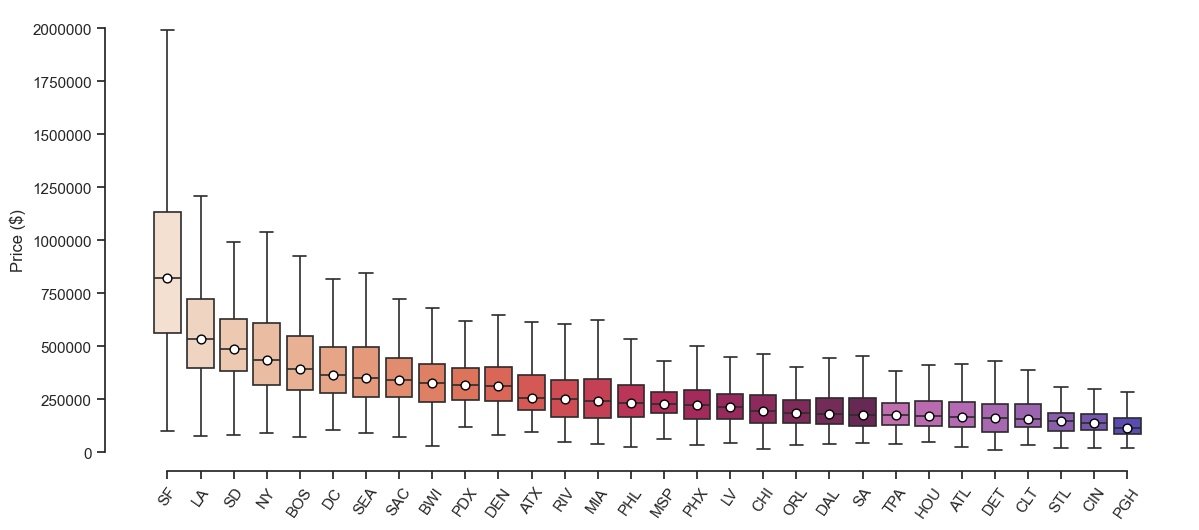

In [28]:
# Boxplot of house prices for the cities, ordered by median price.

top_cities = df["city"].value_counts().head(30).index.tolist()
df_city    = df[df["city"].isin(top_cities)]
city_order = (
    df_city.groupby("city")["price"]
           .median()
           .sort_values(ascending=False)
           .index
)

base = sns.color_palette("rocket_r", len(city_order))

def lighten(color, amt=.4):
    h, l, s = colorsys.rgb_to_hls(*color)
    return colorsys.hls_to_rgb(h, min(1, l + amt*(1-l)), s)

palette = [
    lighten(c, .45) if i >= len(base) - 8 else c
    for i, c in enumerate(base)
]

sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    x="city", y="price", data=df_city,
    order=city_order, palette=palette,
    showfliers=False, linewidth=1.2, ax=ax
)

medians = df_city.groupby("city")["price"].median().loc[city_order]
for tick, median in enumerate(medians):
    ax.scatter(tick, median, color="white", edgecolor="black", zorder=5, s=40)

ax.set_xlabel("")
ax.set_ylabel("Price ($)")
ax.tick_params(axis="x", rotation=55)
sns.despine(trim=True)
ax.grid(False)
ax.ticklabel_format(axis="y", style="plain")

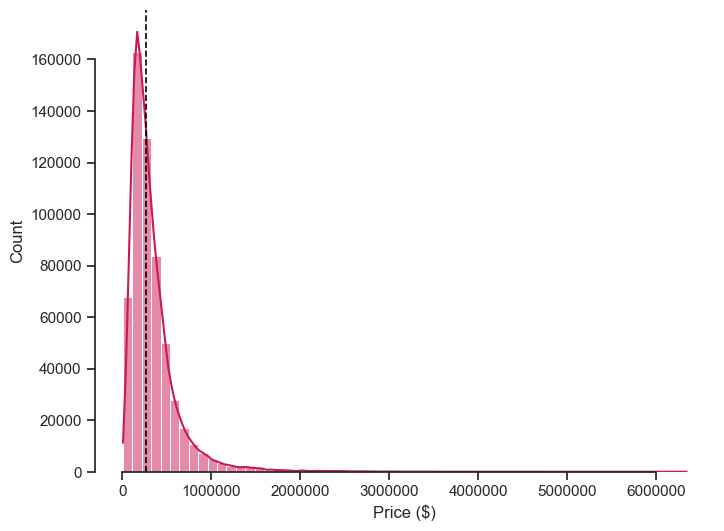

In [29]:
# Distribution of house prices across the dataset

sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(df["price"].dropna(), bins=60, kde=True, color=sns.color_palette("rocket_r", 1)[0], ax=ax)
median_price = df["price"].median()
ax.axvline(median_price, ls="--", lw=1.2, color="black")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Count")
sns.despine(trim=True)
ax.grid(False)
ax.ticklabel_format(axis="x", style="plain")
plt.show()